In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
# Connect to SQLite database
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()


In [3]:
# Try creating the sales table with IF NOT EXISTS
try:
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS sales (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            product TEXT NOT NULL,
            quantity INTEGER NOT NULL,
            price REAL NOT NULL
        )
    ''')
except sqlite3.Error as e:
    print("Error creating table:", e)


In [4]:
# Optional: Clear existing data to avoid duplicates (for development/testing only)
# cursor.execute('DELETE FROM sales')


In [6]:
# Insert sample data if the table is empty
cursor.execute('SELECT COUNT(*) FROM sales')
if cursor.fetchone()[0] == 0:
    sample_data = [
        ('Product A', 10, 5.0),
        ('Product B', 20, 7.5),
        ('Product C', 15, 6.0),
        ('Product A', 5, 5.0),
        ('Product B', 10, 7.5),
        ('Product C', 5, 6.0)
    ]
    try:
        cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
        conn.commit()
    except sqlite3.Error as e:
        print("Error inserting data:", e)


In [7]:
# Run SQL query to get sales summary
query = '''
    SELECT product,
           SUM(quantity) AS total_qty,
           SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
'''

df = pd.read_sql_query(query, conn)
print("Sales Summary:\n", df)


Sales Summary:
   product  total_qty  revenue
0   Apple         15     22.5
1  Banana         25     20.0
2  Grapes          8     20.0
3   Mango         12     36.0
4  Orange         35     42.0


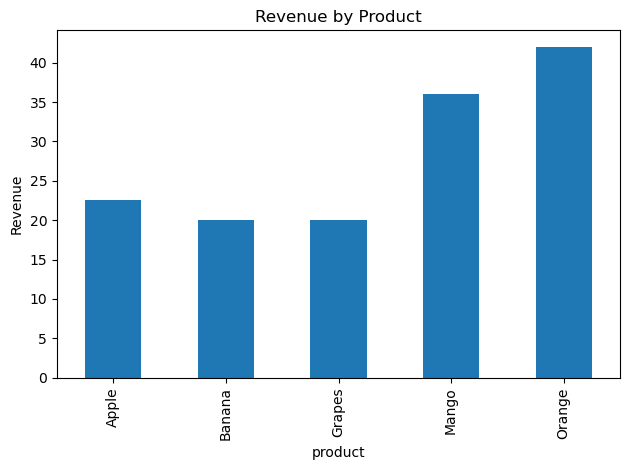

In [8]:
# Plot revenue
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title('Revenue by Product')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('sales_chart.png')
plt.show()


In [9]:
# Close connection
conn.close()